In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy as copy

In [2]:
import sys
sys.path.append('../')
from BPMQ import fmlat, BPMQscan
from BPMQ.construct_machineIO import construct_machineIO

In [3]:
# Example usage (assuming you have the helper functions defined as before):
filename = "lattice.txt"  # Replace with your lattice file
to_elem = "BDS_BTS:PM_D5567"
lattice_dicts = fmlat.combine_lattice_elements_quads_only(filename, from_element=None, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])

quads_to_scan = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
quads_to_scan = quads_to_scan[:2]
BPM_names = [elem['name'] for elem in lattice_dicts if 'BPM' in elem['name']][1:]

In [4]:
machineIO = construct_machineIO()

machineIO.test = True
machineIO._check_chopper_blocking = False
machineIO._fetch_data_time_span = 1
machineIO._ensure_set_timewait_after_ramp = 0.25
machineIO._fetch_data_resample_rate = 0.20022

In [5]:
E_MeVu = 130
Mass_number = 18
Charge_number = 8
args = (E_MeVu, Mass_number, Charge_number)

kwargs = {
    "quads_to_scan": quads_to_scan,
    "quads_max_curr": [180, 180, 180, 180],
    "quads_min_curr": [ 10,  10,  10,  10],
    "BPM_names": BPM_names,
    "lattice_dicts" : lattice_dicts,
    "xnemit_target": None,
    "ynemit_target": None,
    "fit_err":True,
    "bootstrap":True,
    "sample_model_err":True,
    "machineIO": None,
    "plot_history":True, 
    "plot_ellipse":True,
    "virtual_beamQerr": 1.0,
    "virtual_beamQmodelerr": 1.0,
    "BPMQ_model_type":"TIS161_GP",
    "seed":0,    
}

after init, number of training data is 4
 ======== cs_reconstruct ========


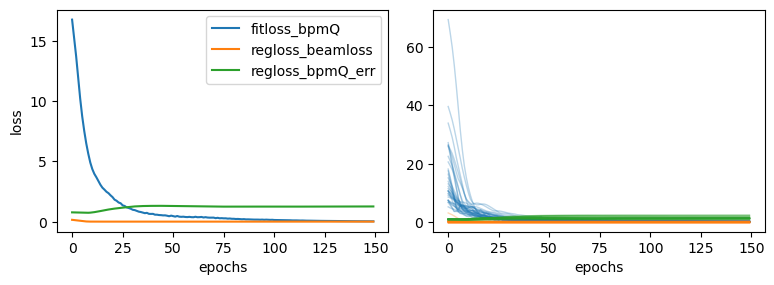

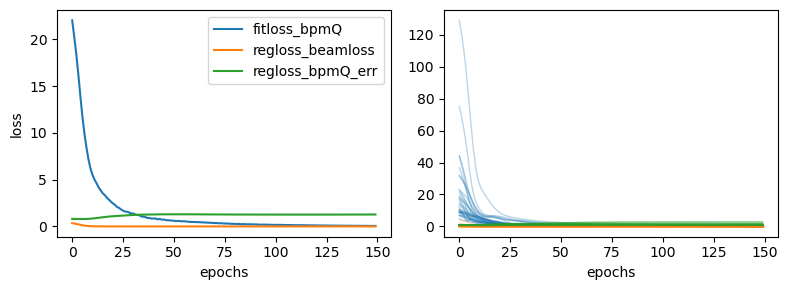

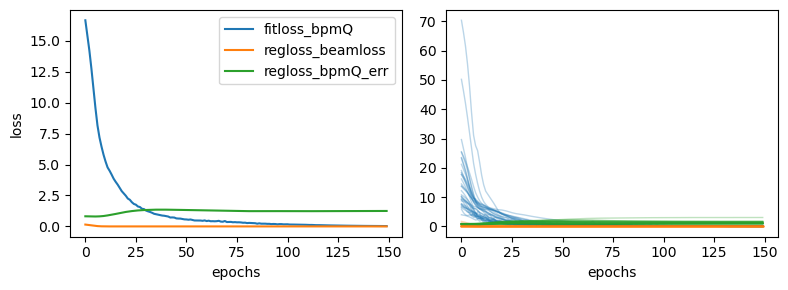

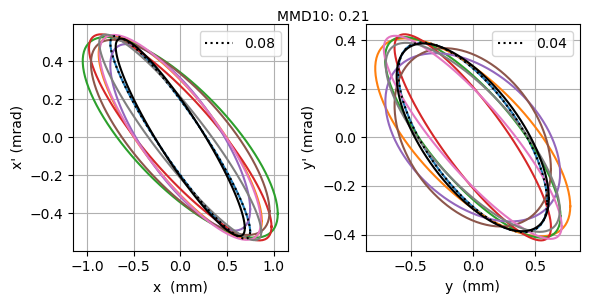

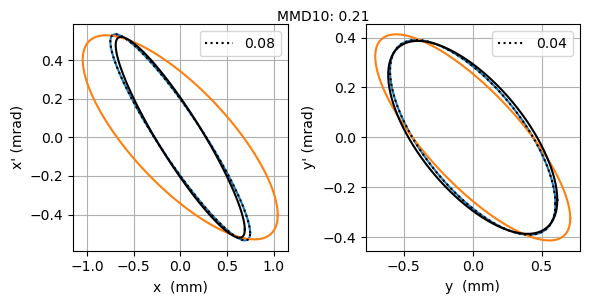

In [6]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs)
bpmQscan.initialize(n_init=4)

 ======== query_candidate_quad_set_maximizing_BPMQ_var ========
Early stopping at iteration 144 due to loss stabilization.


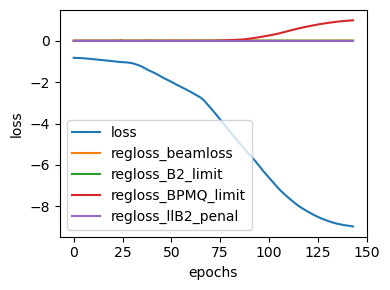

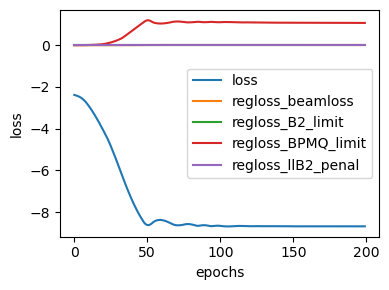

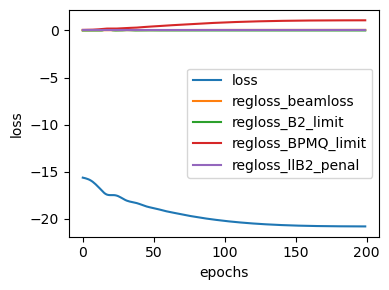

best_loss tensor(-6.9739)
best_regloss_beamloss 0.01135195791721344
 ======== cs_reconstruct ========


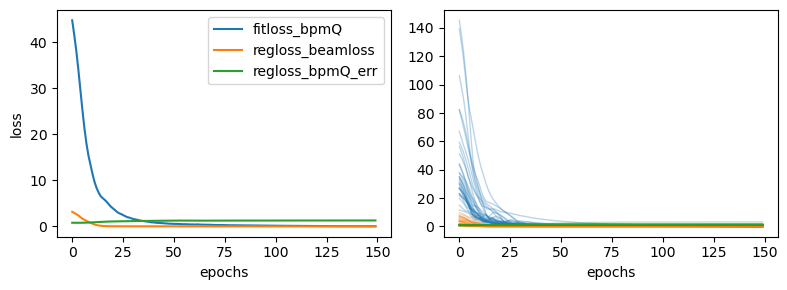

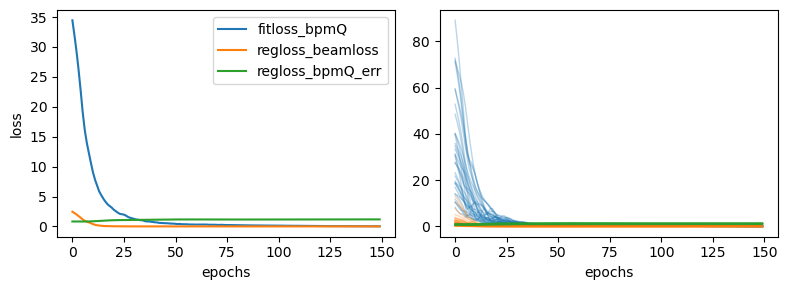

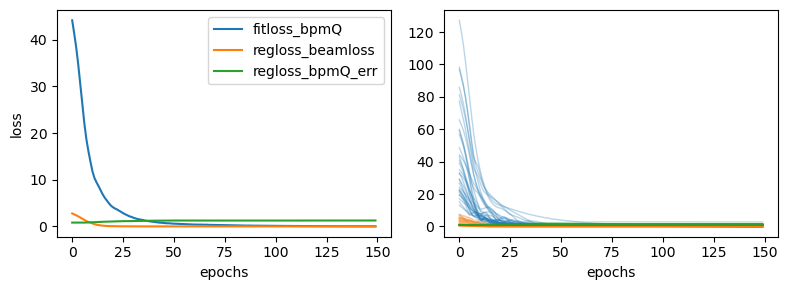

tensor(True)

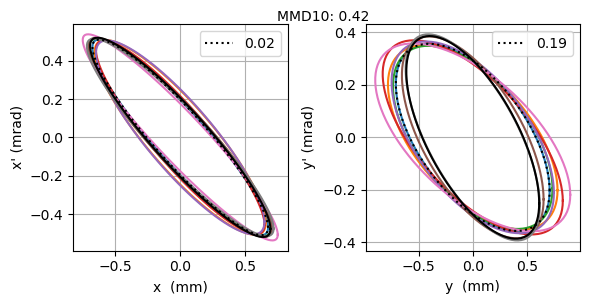

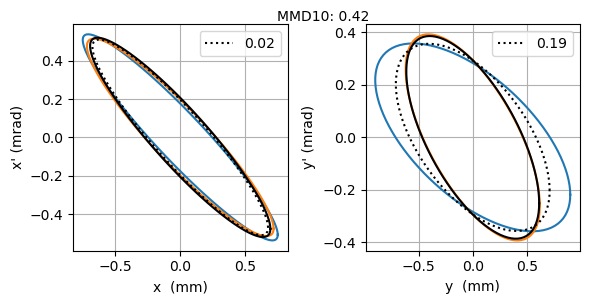

In [7]:
bpmQscan.step()

 ======== query_candidate_quad_set_maximizing_BPMQ_var ========


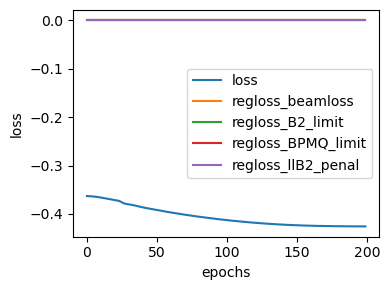

best_loss tensor(-0.4257)
best_regloss_beamloss 0.0
 ======== cs_reconstruct ========


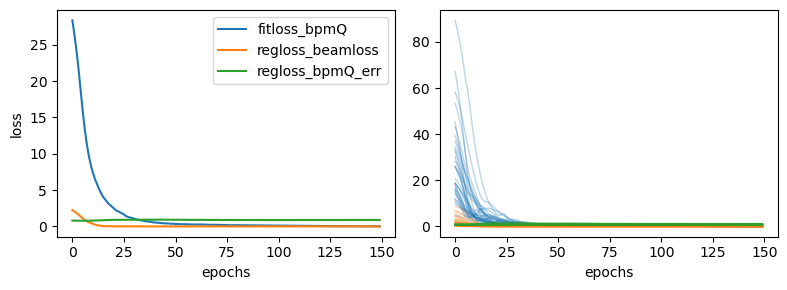

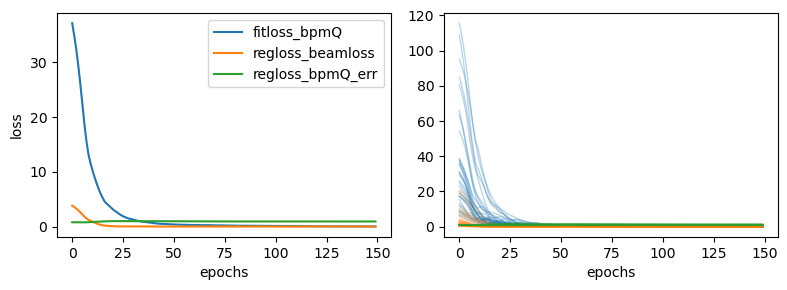

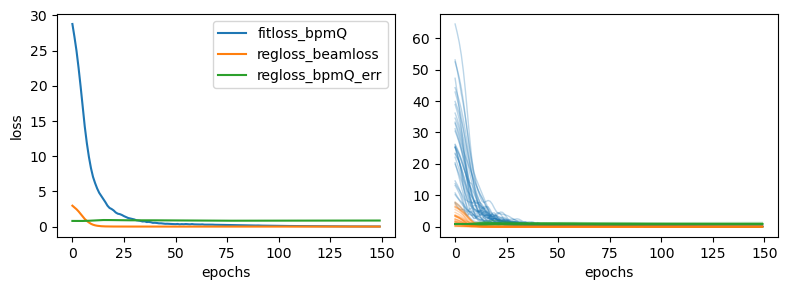

tensor(True)

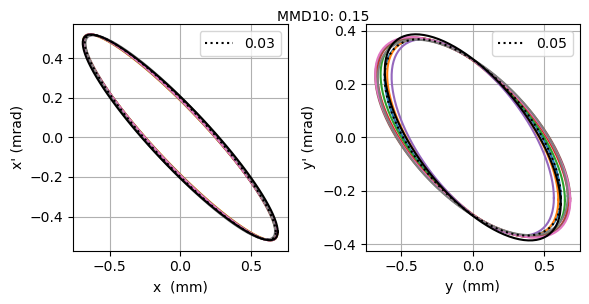

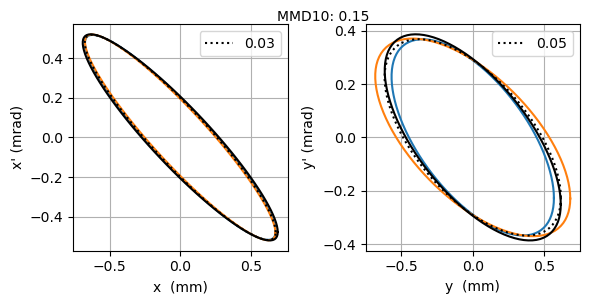

In [8]:
bpmQscan.step(bootstrap=False, sample_model_err=False)